In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/telco_churn_processed.csv")
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,num_services,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr
0,0,1,29.85,29.85,0,1,False,True,False,False,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,2,True,False,False,True,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,2,True,False,False,True,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,3,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,0,False,False,False,True,...,False,False,False,True,False,True,False,False,False,False


In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,num_services,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-6yr
0,0,1,29.85,29.85,1,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,2,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,2,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,3,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,0,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
model = DecisionTreeClassifier(
    random_state=42
)

In [10]:
param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

from sklearn.model_selection import GridSearchCV

model = DecisionTreeClassifier(
    random_state=42, class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',   # VERY important for churn
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [11]:
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20}
Best CV ROC-AUC: 0.8256564904666087


In [12]:
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)
y_pred_proba = best_dt.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.7239176721078779
Precision: 0.48739495798319327
Recall: 0.7754010695187166
F1: 0.5985552115583075
ROC AUC: 0.8272830607868971


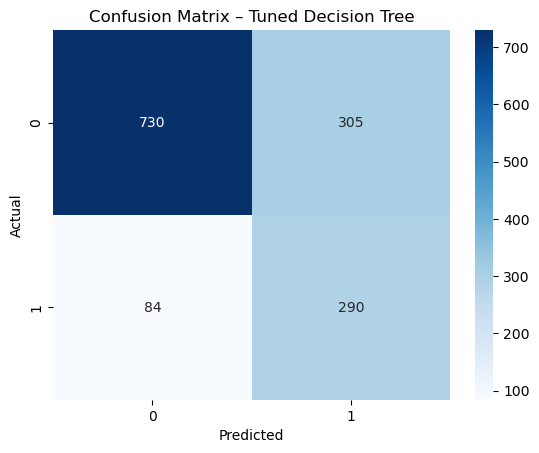

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Tuned Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
26,Contract_Two year,0.393365
25,Contract_One year,0.221414
1,tenure,0.110555
11,InternetService_Fiber optic,0.105819
2,MonthlyCharges,0.048232
24,StreamingMovies_Yes,0.039343
29,PaymentMethod_Electronic check,0.036381
3,TotalCharges,0.031026
23,StreamingMovies_No internet service,0.013864
0,SeniorCitizen,0.000000


In [15]:
import joblib

joblib.dump(best_dt, "../models/decision_tree_tuned.pkl")

['../models/decision_tree_tuned.pkl']